# Distinguish prior distributions

Let's look at how different prior distributions behave.

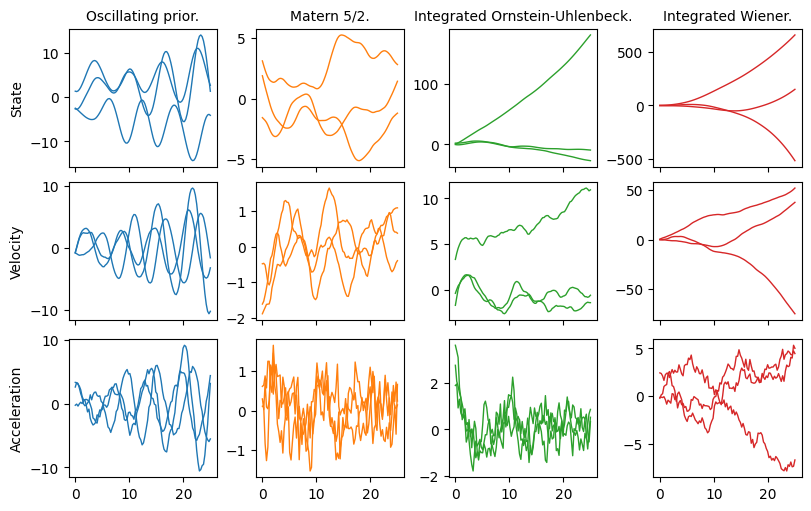

In [1]:
"""Demonstrate prior distributions."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import probdiffeq

ts = jnp.linspace(0.0, 25.0, num=100, endpoint=True)


def vf_matern(u, du, ddu):
    """Matern 5/2."""
    ell = 0.5
    return -(ell**3) * u - 3 * ell**2 * du - 3 * ell * ddu


def vf_oscillator(_u, du, _ddu):
    """Oscillating prior."""
    return -du  # always the second highest coefficient


def vf_ioup(_u, _du, ddu):
    """Integrated Ornstein-Uhlenbeck."""
    return -ddu  # always the highest coefficient


def vf_iwp(u, _du, _ddu):
    """Integrated Wiener."""
    return 0.0 * u  # always zeros


fig, axes = plt.subplots(
    nrows=3, ncols=4, sharex=True, sharey=False, figsize=(8, 5), constrained_layout=True
)
for i, (vf_prior, ax_col) in enumerate(
    zip([vf_oscillator, vf_matern, vf_ioup, vf_iwp], axes.T)
):
    init, ssm = probdiffeq.ssm_taylor_diffuse([0.0, 0.0, 2.0], [2.0, 2.0, 2.0])

    prior = probdiffeq.prior_exponential(vf_prior, ssm=ssm, output_scale=1.0)
    mseq = probdiffeq.MarkovSequence.from_grid(init, prior, grid=ts, reverse=False)

    num_samples = 3
    key = jax.random.PRNGKey(i)
    sample_fun = jax.jit(mseq.sample, static_argnames=["shape", "ssm"])
    samples_prior = sample_fun(key, ssm=ssm, shape=(num_samples,))

    ax_col[0].set_title(vf_prior.__doc__, fontsize="medium")

    for s, ax in zip(samples_prior, ax_col):
        ax.plot(ts, s.T, color=f"C{i}", linewidth=1.0)

axes[0][0].set_ylabel("State", fontsize="medium")
axes[1][0].set_ylabel("Velocity", fontsize="medium")
axes[2][0].set_ylabel("Acceleration", fontsize="medium")


plt.show()